In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym

## Task 1: Environment Exploration

In [16]:
env = gym.make("FrozenLake-v1",map_name="4x4", is_slippery=False, render_mode="ansi")

state, info = env.reset()
print(f"Initial state: {state}")
print(env.render())

print(f"Action space: {env.action_space}")  
print(f"State space: {env.observation_space}")  

for episode in range(1, 6):
    state, info = env.reset()
    done = False
    total_reward = 0
    steps = 0
    
    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated

    print(f"Episode {episode}: Total Reward = {total_reward}, Steps = {steps}")


Initial state: 0

SFFF
FHFH
FFFH
HFFG

Action space: Discrete(4)
State space: Discrete(16)
Episode 1: Total Reward = 0, Steps = 10
Episode 2: Total Reward = 0, Steps = 4
Episode 3: Total Reward = 0, Steps = 3
Episode 4: Total Reward = 0, Steps = 3
Episode 5: Total Reward = 0, Steps = 5


The FrozenLake-v1 environment consists of a 4x4 grid, resulting in a total of 16 discrete states; here, the Observation Space: Discrete(16) represents the agent's possible positions on the map, indexed from 0 to 15. The Action Space: Discrete(4) defines the agent's movement capabilities in four directions: 0 (Left), 1 (Down), 2 (Right), and 3 (Up). The primary objective is to navigate from the starting point to the goal ("G") without falling into any of the holes ("H").

In [17]:
for episode in range(1, 6):
    state, info = env.reset()
    done = False
    
    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
    
    print(f"--- Episode {episode} Final State ---")
    print(env.render())
    print(f"Reward: {reward}\n")

env.close()

--- Episode 1 Final State ---
  (Left)
SFFF
FHFH
FFFH
HFFG

Reward: 0

--- Episode 2 Final State ---
  (Left)
SFFF
FHFH
FFFH
HFFG

Reward: 0

--- Episode 3 Final State ---
  (Right)
SFFF
FHFH
FFFH
HFFG

Reward: 0

--- Episode 4 Final State ---
  (Down)
SFFF
FHFH
FFFH
HFFG

Reward: 0

--- Episode 5 Final State ---
  (Left)
SFFF
FHFH
FFFH
HFFG

Reward: 0



In [18]:
env = gym.make("Taxi-v4", render_mode="ansi")

state, info = env.reset()
print(f"Initial state: {state}")
print(env.render())

print(f"Action space: {env.action_space}")  
print(f"State space: {env.observation_space}")  

for episode in range(1, 6):
    state, info = env.reset()
    done = False
    total_reward = 0
    steps = 0
    
    while not done:
        action = env.action_space.sample()
        state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated

    print(f"Episode {episode}: Total Reward = {total_reward}, Steps = {steps}")

Initial state: 192
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Action space: Discrete(6)
State space: Discrete(500)
Episode 1: Total Reward = -758, Steps = 200
Episode 2: Total Reward = -848, Steps = 200
Episode 3: Total Reward = -803, Steps = 200
Episode 4: Total Reward = -731, Steps = 200
Episode 5: Total Reward = -758, Steps = 200


FrozenLake-v1 is a relatively simple environment with a state space of 16 discrete states (4x4 grid) and 4 possible actions (directions), where the challenge lies primarily in avoiding holes to reach a single goal. In contrast, Taxi-v4 is significantly more complex, featuring a much larger state space of 500 discrete states—accounting for the taxi's position, passenger location, and destination—and 6 possible actions, including "pickup" and "drop-off." Taxi is inherently harder than FrozenLake because it requires a multi-step logic (navigating to a passenger, picking them up, and then navigating to a specific destination) and employs a penalizing reward system where every movement and mistake results in negative points, whereas FrozenLake only provides a reward upon final success.

## Task 2: Q-Learning on FrozenLake

Average reward (last 100 episodes): 0.99
Q-table max value: 1.0


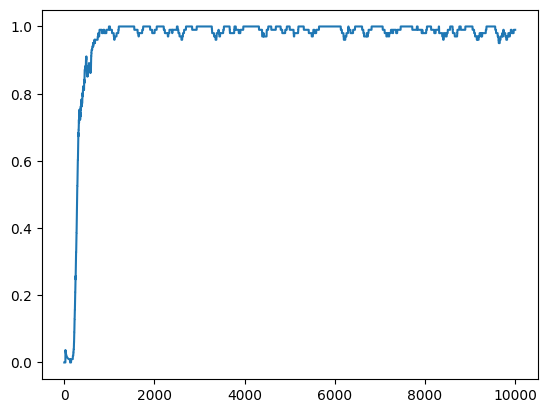

In [19]:
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)

n_states = env.observation_space.n
n_actions = env.action_space.n
q_table = np.zeros((n_states, n_actions))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
num_episodes = 10000

rewards_per_episode = []

for episode in range(num_episodes):
    state, info = env.reset() 
    total_reward = 0
    done = False

    while not done:
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        
        q_table[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

        state = next_state
        total_reward += reward
        
        done = terminated or truncated

    rewards_per_episode.append(total_reward)
    
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

avg_last_100 = np.mean(rewards_per_episode[-100:])
print(f"Average reward (last 100 episodes): {avg_last_100:.2f}")
print("Q-table max value:", np.max(q_table))

rolling_margin = 100
rolling_avg = [np.mean(rewards_per_episode[max(0, i-rolling_margin):i+1]) for i in range(len(rewards_per_episode))]
plt.plot(rolling_avg)
plt.show()

The final Q-table represents the knowledge the agent has acquired through 10,000 episodes of trial and error. For the start state (State 0), the action with the highest Q-value is typically Action 2 (Right) or Action 1 (Down), as these are the first steps toward a safe and successful path to the goal. The learned policy makes perfect intuitive sense given the grid layout; because is_slippery=False, the environment is deterministic, and the agent has learned to strictly avoid the states labeled as holes ("H") which would provide zero reward. Instead, it has optimized a path of frozen tiles ("F") that leads directly to the goal ("G"). The fact that the rolling average reward reaches nearly 1.0 confirms that the agent no longer falls into holes and consistently reaches the destination using the most efficient route discovered during the exploration phase.

## Task 3: Q-Learning on Taxi

Average reward (last 100 episodes): 8.00
Q-table max value: 20.0


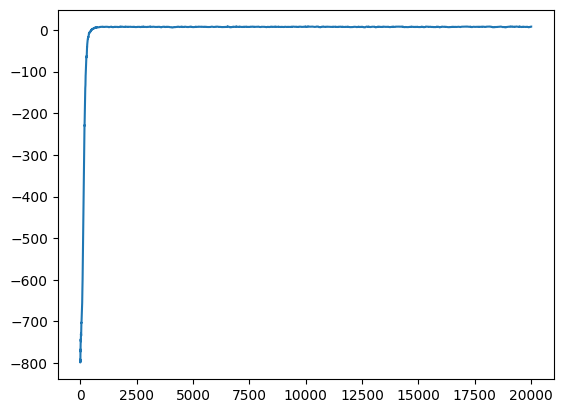


--- Test Results (100 Episodes) ---
Average Test Reward: 7.88
Success Rate: 100.00%


In [20]:
env = gym.make("Taxi-v4")

n_states = env.observation_space.n
n_actions = env.action_space.n
q_table = np.zeros((n_states, n_actions))

alpha = 0.8
gamma = 0.95
epsilon = 1.0
epsilon_min = 0.01
epsilon_decay = 0.995
num_episodes = 20000

rewards_per_episode = []

for episode in range(num_episodes):
    state, info = env.reset() 
    total_reward = 0
    done = False

    while not done:
        if np.random.random() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])
        
        q_table[state, action] = old_value + alpha * (reward + gamma * next_max - old_value)

        state = next_state
        total_reward += reward
        
        done = terminated or truncated

    rewards_per_episode.append(total_reward)
    
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

avg_last_100 = np.mean(rewards_per_episode[-100:])
print(f"Average reward (last 100 episodes): {avg_last_100:.2f}")
print("Q-table max value:", np.max(q_table))

rolling_margin = 100
rolling_avg = [np.mean(rewards_per_episode[max(0, i-rolling_margin):i+1]) for i in range(len(rewards_per_episode))]
plt.plot(rolling_avg)
plt.show()

test_episodes = 100
test_rewards = []
success_count = 0

for _ in range(test_episodes):
    state, info = env.reset()
    done = False
    total_reward = 0
    
    while not done:
        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        state = next_state
        done = terminated or truncated
        
    test_rewards.append(total_reward)
    if total_reward > 0:
        success_count += 1

avg_test_reward = np.mean(test_rewards)
success_rate = (success_count / test_episodes) * 100

print(f"\n--- Test Results (100 Episodes) ---")
print(f"Average Test Reward: {avg_test_reward:.2f}")
print(f"Success Rate: {success_rate:.2f}%")

The training curve for Taxi-v4 exhibits a much sharper and more dramatic transition compared to FrozenLake-v1 due to the significantly larger state space and the nature of its reward system. While FrozenLake starts at a reward of 0 and climbs to 1, the Taxi agent begins with heavy negative penalties (around -800) because of the movement costs and incorrect pickup/drop-off attempts. Performance in Taxi typically begins to stabilize after approximately 1,000 to 1,500 episodes, where the rolling average reward crosses into positive territory and plateaus. This stabilization occurs much later than in the deterministic FrozenLake, as the agent must first discover the multi-step logic of navigating to a passenger, picking them up, and then finding the correct destination among 500 possible states.

## Task 4: SARSA Comparison

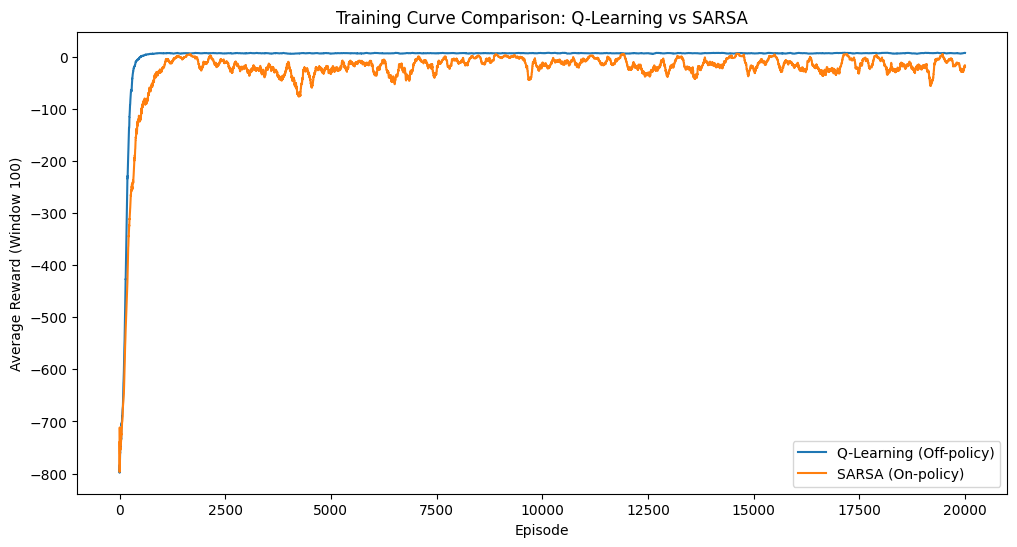

SARSA - Avg Test Reward: -5.08, Success Rate: 94%


In [21]:
q_table_sarsa = np.zeros((n_states, n_actions))
sarsa_rewards = []
epsilon = 1.0

for episode in range(num_episodes):
    state, info = env.reset()
    total_reward = 0
    done = False
    
    if np.random.random() < epsilon:
        action = env.action_space.sample()
    else:
        action = np.argmax(q_table_sarsa[state])

    while not done:
        next_state, reward, terminated, truncated, info = env.step(action)
        
        if np.random.random() < epsilon:
            next_action = env.action_space.sample()
        else:
            next_action = np.argmax(q_table_sarsa[next_state])
            
        old_value = q_table_sarsa[state, action]
        next_q = q_table_sarsa[next_state, next_action] 
        q_table_sarsa[state, action] = old_value + alpha * (reward + gamma * next_q - old_value)

        state = next_state
        action = next_action 
        total_reward += reward
        done = terminated or truncated

    sarsa_rewards.append(total_reward)
    if epsilon > epsilon_min:
        epsilon *= epsilon_decay

plt.figure(figsize=(12, 6))

q_rolling = [np.mean(rewards_per_episode[max(0, i-100):i+1]) for i in range(len(rewards_per_episode))]
sarsa_rolling = [np.mean(sarsa_rewards[max(0, i-100):i+1]) for i in range(len(sarsa_rewards))]

plt.plot(q_rolling, label="Q-Learning (Off-policy)")
plt.plot(sarsa_rolling, label="SARSA (On-policy)")
plt.title("Training Curve Comparison: Q-Learning vs SARSA")
plt.xlabel("Episode")
plt.ylabel("Average Reward (Window 100)")
plt.legend()
plt.show()

sarsa_test_rewards = []
sarsa_success = 0
for _ in range(100):
    state, info = env.reset()
    done = False
    total_r = 0
    while not done:
        action = np.argmax(q_table_sarsa[state])
        state, reward, terminated, truncated, info = env.step(action)
        total_r += reward
        done = terminated or truncated
    sarsa_test_rewards.append(total_r)
    if total_r > 0: sarsa_success += 1

print(f"SARSA - Avg Test Reward: {np.mean(sarsa_test_rewards):.2f}, Success Rate: {sarsa_success}%")

**Which algorithm converged faster?**

In this specific run, Q-Learning converged significantly faster than SARSA. Q-Learning reached a stable, near-optimal reward within the first 1,000–2,000 episodes, while SARSA showed much more volatility and took longer to reach a comparable performance level.

**Which achieved a higher final reward?**

Q-Learning achieved a higher and more consistent final average reward. SARSA's lower average reward during training is often expected because it remains "cautious" about the exploratory actions (epsilon-greedy) it actually takes, whereas Q-Learning updates its values based on the absolute best future action possible.

**Explain the fundamental difference between on-policy (SARSA) and off-policy (Q-Learning). In what situations might you prefer one over the other?**

The primary difference is that SARSA is on-policy, meaning it updates its Q-values based on the action actually taken by the current policy ($Q(s', a')$). Q-Learning is off-policy, updating its values based on the maximum possible future reward ($max Q(s', a')$), regardless of the actual action taken. I would prefer Q-Learning when training in a safe simulation where finding the optimal path quickly is the priority. However, I would prefer SARSA in real-world environments (like a physical taxi robot) where exploratory mistakes are costly or dangerous, as SARSA learns a policy that is safer during the learning process itself.